In [46]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os

# ====== USER CONFIG ===========================================================
CSV_PATH = Path("/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t5/synched_data/final_annotation_t5.csv")   # <— change if needed

# If you know the label column, set it here; else it will be auto-guessed.
LABEL_COL = None  # e.g., "gesture" or "activity"

# Choose which modality to run PCA on (any key from MODALITY_COLUMNS below).
MODALITY_KEY = "console"        # e.g., "console", "raven", "trakstar_raw", "trakstar_trans", "handkp", "images"

# How many PCs to compute (>= max(PC_PAIR))
N_COMPONENTS = 4                # e.g., 3, 6, 10 …

# Which two PCs to show (1-based indices): (1,2) or (1,3) or (2,3), etc.
PC_PAIR = (1, 2)

# Optional downsampling for faster plots (keep 1 to use all rows)
DOWNSAMPLE_EVERY_N_ROWS = 1

# Save figures?
SAVE_FIGS = True
OUTDIR = Path("./pca_outputs")
os.makedirs(OUTDIR, exist_ok=True)
# ==============================================================================


# ====== YOUR COLUMN LISTS =====================================================
MODALITY_COLUMNS = {
    "console": [
        "console_pos0","console_pos1","console_pos2","console_pos3","console_pos4","console_pos5",
        "console_rot0","console_rot1","console_rot2","console_rot3","console_rot4","console_rot5",
        "console_aux0","console_aux1","console_pedal"
    ],
    "raven": [
        "raven_field.pos0","raven_field.pos1","raven_field.pos2","raven_field.pos3","raven_field.pos4","raven_field.pos5",
        "raven_field.ori0","raven_field.ori1","raven_field.ori2","raven_field.ori3","raven_field.ori4","raven_field.ori5",
        # Uncomment if you want all orientation channels:
        # "raven_field.ori6","raven_field.ori7","raven_field.ori8","raven_field.ori9","raven_field.ori10","raven_field.ori11",
        # "raven_field.ori12","raven_field.ori13","raven_field.ori14","raven_field.ori15","raven_field.ori16","raven_field.ori17"
    ],
    # Placeholder if you later add columns for framewise ResNet feats (e.g., resnet_0..2047)
    "images": ["resnet"],

    # Two flavors of TrakStar (raw and transformed); pick the key you want
    "trakstar_raw": [
        "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
        "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
        "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
        "trakstar_sensor_0_x","trakstar_sensor_1_x","trakstar_sensor_2_x","trakstar_sensor_3_x",
        "trakstar_sensor_0_y","trakstar_sensor_1_y","trakstar_sensor_2_y","trakstar_sensor_3_y",
        "trakstar_sensor_0_z","trakstar_sensor_1_z","trakstar_sensor_2_z","trakstar_sensor_3_z"
    ],
    "trakstar_trans": [
        "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
        "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
        "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
        "trakstar_sensor_0_x_transformed","trakstar_sensor_0_y_transformed","trakstar_sensor_0_z_transformed",
        "trakstar_sensor_1_x_transformed","trakstar_sensor_1_y_transformed","trakstar_sensor_1_z_transformed",
        "trakstar_sensor_2_x_transformed","trakstar_sensor_2_y_transformed","trakstar_sensor_2_z_transformed",
        "trakstar_sensor_3_x_transformed","trakstar_sensor_3_y_transformed","trakstar_sensor_3_z_transformed"
        # ,"trakstar_grasp_d0","trakstar_grasp_d1"
    ],

    "sw_left":  ["sw_left_x"],
    "sw_right": ["sw_right_x"],

    "handkp": [
        "hand_left X","hand_left Y","hand_left Z","hand_left Yaw","hand_left Pitch","hand_left Roll",
        "hand_right X","hand_right Y","hand_right Z","hand_right Yaw","hand_right Pitch","hand_right Roll"
        # If you want fingertips later, append:
        # ,"hand_left_index_tip_X","hand_left_index_tip_Y","hand_left_index_tip_Z",
        #  "hand_right_index_tip_X","hand_right_index_tip_Y","hand_right_index_tip_Z",
        #  "hand_left_thumb_tip_X","hand_left_thumb_tip_Y","hand_left_thumb_tip_Z",
        #  "hand_right_thumb_tip_X","hand_right_thumb_tip_Y","hand_right_thumb_tip_Z"
    ],
}


# ====== UTILITIES ==============================================================

def guess_label_column(df: pd.DataFrame) -> str:
    preferred = ["gesture", "gesture_label", "activity", "activity_label",
                 "label", "keystep", "keystep_label", "gesture_name", "class"]
    for name in preferred:
        for c in df.columns:
            if c.lower() == name.lower():
                return c
    # fallback: pick a low-cardinality column
    candidates = []
    for c in df.columns:
        lower = c.lower()
        if any(t in lower for t in ["time", "timestamp", "frame", "index"]):
            continue
        nunique = df[c].nunique(dropna=True)
        if 1 < nunique <= 40:
            if df[c].dtype == object:
                candidates.append((c, nunique))
            else:
                if nunique / max(1, len(df)) < 0.05:
                    candidates.append((c, nunique))
    if candidates:
        candidates.sort(key=lambda x: x[1])
        return candidates[0][0]
    df["_auto_label"] = "all"
    return "_auto_label"


def build_feature_matrix(df: pd.DataFrame, cols: list[str]) -> tuple[np.ndarray, list[str]]:
    """Return (X, used_cols) after intersecting with df and warning on any missing."""
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"[Warn] {len(missing)} columns not found and will be skipped (showing up to 8): {missing[:8]}")
    used = [c for c in cols if c in df.columns]
    if not used:
        raise ValueError("None of the requested modality columns exist in the CSV.")
    X = df[used].to_numpy()
    return X, used


def pca_plot(X: np.ndarray, y: np.ndarray, modality_name: str,
             n_components: int, pc_pair: tuple[int, int], save_dir) -> None:
    # Drop rows with NaNs in the selected features
    valid = np.isfinite(X).all(axis=1)
    X = X[valid]
    y = y[valid]
    if X.shape[0] < 10:
        raise ValueError(f"Not enough valid rows after NaN filtering: {X.shape[0]}")

    # Standardize then PCA
    Xs = StandardScaler().fit_transform(X)
    n_components = int(max(n_components, max(pc_pair)))  # ensure we have enough PCs
    pca = PCA(n_components=n_components).fit(Xs)
    Z = pca.transform(Xs)  # [n, n_components]

    i, j = pc_pair
    pc_i, pc_j = i - 1, j - 1
    if pc_i >= Z.shape[1] or pc_j >= Z.shape[1]:
        raise ValueError(f"PC_PAIR {pc_pair} exceeds computed components ({Z.shape[1]}). Increase N_COMPONENTS.")

    # Scatter PCi vs PCj
    plt.figure(figsize=(8, 6))
    y_cat = pd.Series(y).astype("category")
    codes = y_cat.cat.codes.values
    for code in np.unique(codes):
        idx = codes == code
        plt.scatter(Z[idx, pc_i], Z[idx, pc_j], s=8, alpha=0.7, label=str(y_cat.cat.categories[code]))
    plt.xlabel(f"PC{i} ({pca.explained_variance_ratio_[pc_i]:.2%})")
    plt.ylabel(f"PC{j} ({pca.explained_variance_ratio_[pc_j]:.2%})")
    plt.title(f"{modality_name} — PCA (PC{i} vs PC{j})")
    plt.legend(markerscale=2, fontsize=8, loc="best")
    plt.tight_layout()
    if SAVE_FIGS and save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_dir / f"{modality_name}_PC{i}_vs_PC{j}.png", dpi=200)
    plt.show()

    # Explained variance bar plot
    evr = pca.explained_variance_ratio_
    plt.figure(figsize=(7, 4))
    xs = np.arange(1, len(evr) + 1)
    plt.bar(xs, evr)
    plt.xticks(xs, [f"PC{k}" for k in xs])
    plt.ylabel("Explained variance ratio")
    plt.title(f"{modality_name} — PCA explained variance (first {len(evr)} PCs)")
    plt.tight_layout()
    if SAVE_FIGS and save_dir:
        plt.savefig(save_dir / f"{modality_name}_explained_variance.png", dpi=200)
    plt.show()

    # Optional quick separation metric on the shown 2D plane
    if len(np.unique(y)) > 1:
        try:
            sil = silhouette_score(Z[:, [pc_i, pc_j]], y_cat.cat.codes.values, metric="euclidean")
            print(f"[Info] Silhouette on PC{i}–PC{j}: {sil:.3f}  (≈[-1,1], higher=better separation)")
        except Exception as e:
            print(f"[Warn] Silhouette failed: {e}")

    # Also print cumulative variance for convenience
    cum = np.cumsum(evr)
    print("[Info] Cumulative explained variance:")
    for k in range(1, min(10, len(evr)) + 1):
        print(f"  PCs 1..{k}: {cum[k-1]:.2%}")


def do_pca_analysis():
    df = pd.read_csv(CSV_PATH)
    print(df.columns.tolist())

    # drop rows where column console_pedal is 0
    df = df[df["console_pedal"] != 0]

    label_col = LABEL_COL or guess_label_column(df)
    print(f"[Label] Using label column: {label_col!r}")
    labels = df[label_col].astype(str).values

    if MODALITY_KEY not in MODALITY_COLUMNS:
        raise KeyError(f"MODALITY_KEY '{MODALITY_KEY}' not in {list(MODALITY_COLUMNS.keys())}")

    cols = MODALITY_COLUMNS[MODALITY_KEY]
    print(f"[Modality] {MODALITY_KEY} with {len(cols)} requested columns")
    X, used_cols = build_feature_matrix(df, cols)
    print(f"[Modality] Using {len(used_cols)} columns found in CSV")

    # Optional downsampling
    if DOWNSAMPLE_EVERY_N_ROWS > 1:
        X = X[::DOWNSAMPLE_EVERY_N_ROWS]
        y = labels[::DOWNSAMPLE_EVERY_N_ROWS]
    else:
        y = labels

    pca_plot(X, y, MODALITY_KEY, N_COMPONENTS, PC_PAIR, save_dir=OUTDIR if SAVE_FIGS else None)




['frame_number', 'timestamp', 'gesture_code', 'gesture_name', 'obs_frame_idx', 'server_time', 'pds_time_ns', 'pds_delta_ns', 'trakstar_time_ns', 'trakstar_delta_ns', 'sw_left_time_ns', 'sw_left_delta_ns', 'sw_right_time_ns', 'sw_right_delta_ns', 'raven_console_time_ns', 'raven_console_delta_ns', 'Pedal 1 Pressure', 'Pedal 2 Pressure', 'Pedal 3 Pressure', 'Pedal 4 Pressure', 'Pedal 6 Pressure', 'Pedal 7 Pressure', 'Pedal 1 Pressed', 'Pedal 2 Pressed', 'Pedal 3 Pressed', 'Pedal 4 Pressed', 'Pedal 5 Pressesd', 'Pedal 6 Pressed', 'Pedal 7 Pressed', 'trakstar_sensor_0_azimuth', 'trakstar_sensor_1_azimuth', 'trakstar_sensor_2_azimuth', 'trakstar_sensor_3_azimuth', 'trakstar_sensor_0_elevation', 'trakstar_sensor_1_elevation', 'trakstar_sensor_2_elevation', 'trakstar_sensor_3_elevation', 'trakstar_sensor_0_roll', 'trakstar_sensor_1_roll', 'trakstar_sensor_2_roll', 'trakstar_sensor_3_roll', 'trakstar_sensor_0_x', 'trakstar_sensor_1_x', 'trakstar_sensor_2_x', 'trakstar_sensor_3_x', 'trakstar_sen

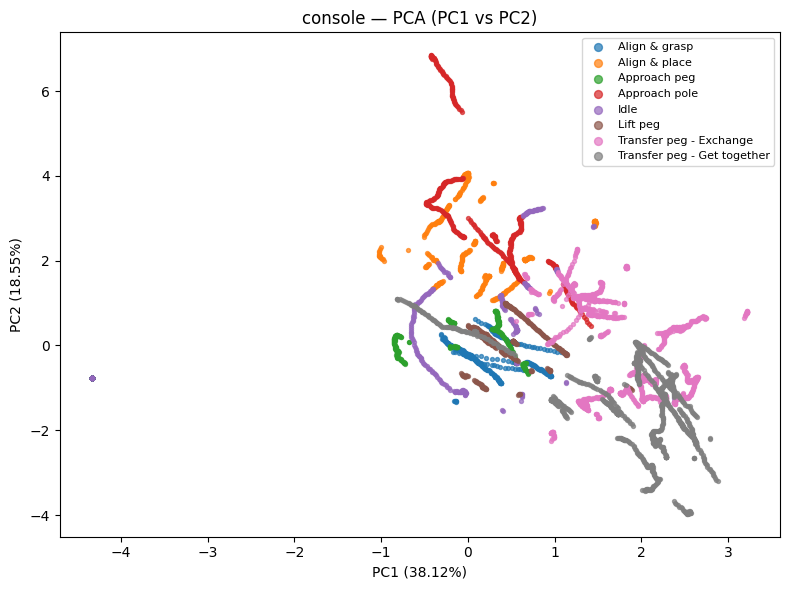

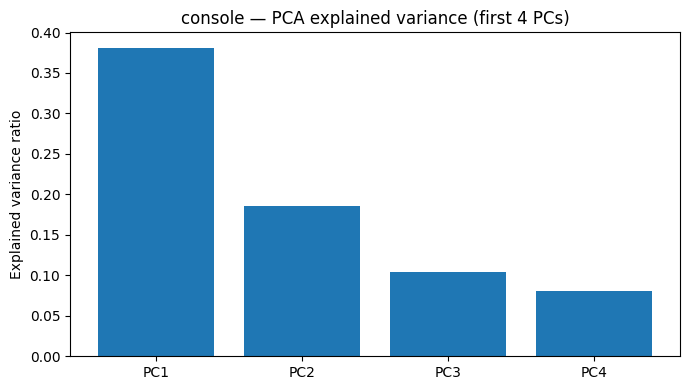

[Info] Silhouette on PC1–PC2: -0.038  (≈[-1,1], higher=better separation)
[Info] Cumulative explained variance:
  PCs 1..1: 38.12%
  PCs 1..2: 56.67%
  PCs 1..3: 67.07%
  PCs 1..4: 75.10%


['frame_number',
 'timestamp',
 'gesture_code',
 'gesture_name',
 'obs_frame_idx',
 'server_time',
 'trakstar_time_ns',
 'trakstar_delta_ns',
 'sw_left_time_ns',
 'sw_left_delta_ns',
 'sw_right_time_ns',
 'sw_right_delta_ns',
 'raven_console_time_ns',
 'raven_console_delta_ns',
 'trakstar_sensor_0_azimuth',
 'trakstar_sensor_1_azimuth',
 'trakstar_sensor_2_azimuth',
 'trakstar_sensor_3_azimuth',
 'trakstar_sensor_0_elevation',
 'trakstar_sensor_1_elevation',
 'trakstar_sensor_2_elevation',
 'trakstar_sensor_3_elevation',
 'trakstar_sensor_0_roll',
 'trakstar_sensor_1_roll',
 'trakstar_sensor_2_roll',
 'trakstar_sensor_3_roll',
 'trakstar_sensor_0_x',
 'trakstar_sensor_1_x',
 'trakstar_sensor_2_x',
 'trakstar_sensor_3_x',
 'trakstar_sensor_0_y',
 'trakstar_sensor_1_y',
 'trakstar_sensor_2_y',
 'trakstar_sensor_3_y',
 'trakstar_sensor_0_z',
 'trakstar_sensor_1_z',
 'trakstar_sensor_2_z',
 'trakstar_sensor_3_z',
 'trakstar_grasp_d0',
 'trakstar_grasp_d1',
 'trakstar_sensor_1_x_transformed

In [47]:
do_pca_analysis()
['frame_number', 'timestamp', 'gesture_code', 'gesture_name', 'obs_frame_idx', 'server_time', 'trakstar_time_ns', 'trakstar_delta_ns', 'sw_left_time_ns', 'sw_left_delta_ns', 'sw_right_time_ns', 'sw_right_delta_ns', 'raven_console_time_ns', 'raven_console_delta_ns', 'trakstar_sensor_0_azimuth', 'trakstar_sensor_1_azimuth', 'trakstar_sensor_2_azimuth', 'trakstar_sensor_3_azimuth', 'trakstar_sensor_0_elevation', 'trakstar_sensor_1_elevation', 'trakstar_sensor_2_elevation', 'trakstar_sensor_3_elevation', 'trakstar_sensor_0_roll', 'trakstar_sensor_1_roll', 'trakstar_sensor_2_roll', 'trakstar_sensor_3_roll', 'trakstar_sensor_0_x', 'trakstar_sensor_1_x', 'trakstar_sensor_2_x', 'trakstar_sensor_3_x', 'trakstar_sensor_0_y', 'trakstar_sensor_1_y', 'trakstar_sensor_2_y', 'trakstar_sensor_3_y', 'trakstar_sensor_0_z', 'trakstar_sensor_1_z', 'trakstar_sensor_2_z', 'trakstar_sensor_3_z', 'trakstar_grasp_d0', 'trakstar_grasp_d1', 'trakstar_sensor_1_x_transformed', 'trakstar_sensor_1_y_transformed', 'trakstar_sensor_1_z_transformed', 'trakstar_sensor_2_x_transformed', 'trakstar_sensor_2_y_transformed', 'trakstar_sensor_2_z_transformed', 'trakstar_sensor_0_x_transformed', 'trakstar_sensor_0_y_transformed', 'trakstar_sensor_0_z_transformed', 'trakstar_sensor_3_x_transformed', 'trakstar_sensor_3_y_transformed', 'trakstar_sensor_3_z_transformed', 'console_pedal_x', 'trakstar_sensor_1_x_transformed_cum', 'trakstar_sensor_1_y_transformed_cum', 'trakstar_sensor_1_z_transformed_cum', 'trakstar_s1_norm_cum', 'trakstar_sensor_2_x_transformed_cum', 'trakstar_sensor_2_y_transformed_cum', 'trakstar_sensor_2_z_transformed_cum', 'trakstar_s2_norm_cum', 'trakstar_sensor_0_x_transformed_cum', 'trakstar_sensor_0_y_transformed_cum', 'trakstar_sensor_0_z_transformed_cum', 'trakstar_s0_norm_cum', 'trakstar_sensor_3_x_transformed_cum', 'trakstar_sensor_3_y_transformed_cum', 'trakstar_sensor_3_z_transformed_cum', 'trakstar_s3_norm_cum', 'sw_left_x', 'sw_left_y', 'sw_left_z', 'sw_right_x', 'sw_right_y', 'sw_right_z', 'seq', 'console_pos0', 'console_pos1', 'console_pos2', 'console_pos3', 'console_pos4', 'console_pos5', 'console_rot0', 'console_rot1', 'console_rot2', 'console_rot3', 'console_rot4', 'console_rot5', 'console_aux0', 'console_aux1', 'console_pedal_y', 'raven_field.pos0', 'raven_field.pos1', 'raven_field.pos2', 'raven_field.pos3', 'raven_field.pos4', 'raven_field.pos5', 'raven_field.ori0', 'raven_field.ori1', 'raven_field.ori2', 'raven_field.ori3', 'raven_field.ori4', 'raven_field.ori5', 'raven_field.ori6', 'raven_field.ori7', 'raven_field.ori8', 'raven_field.ori9', 'raven_field.ori10', 'raven_field.ori11', 'raven_field.ori12', 'raven_field.ori13', 'raven_field.ori14', 'raven_field.ori15', 'raven_field.ori16', 'raven_field.ori17', 'raven_field.grasp_d0', 'raven_field.grasp_d1', 'console_pos0_transformed', 'console_pos1_transformed', 'console_pos2_transformed', 'console_pos3_transformed', 'console_pos4_transformed', 'console_pos5_transformed', 'server_time_ns', 'hand_timestamp_ns', 'hand_Frame', 'hand_left X', 'hand_left Y', 'hand_left Z', 'hand_left Yaw', 'hand_left Pitch', 'hand_left Roll', 'hand_right X', 'hand_right Y', 'hand_right Z', 'hand_right Yaw', 'hand_right Pitch', 'hand_right Roll', 'hand_left_index_tip_X', 'hand_left_index_tip_Y', 'hand_left_index_tip_Z', 'hand_right_index_tip_X', 'hand_right_index_tip_Y', 'hand_right_index_tip_Z', 'hand_left_thumb_tip_X', 'hand_left_thumb_tip_Y', 'hand_left_thumb_tip_Z', 'hand_right_thumb_tip_X', 'hand_right_thumb_tip_Y', 'hand_right_thumb_tip_Z']


[Label] Using: gesture_name
[Modality] console: using 15 columns


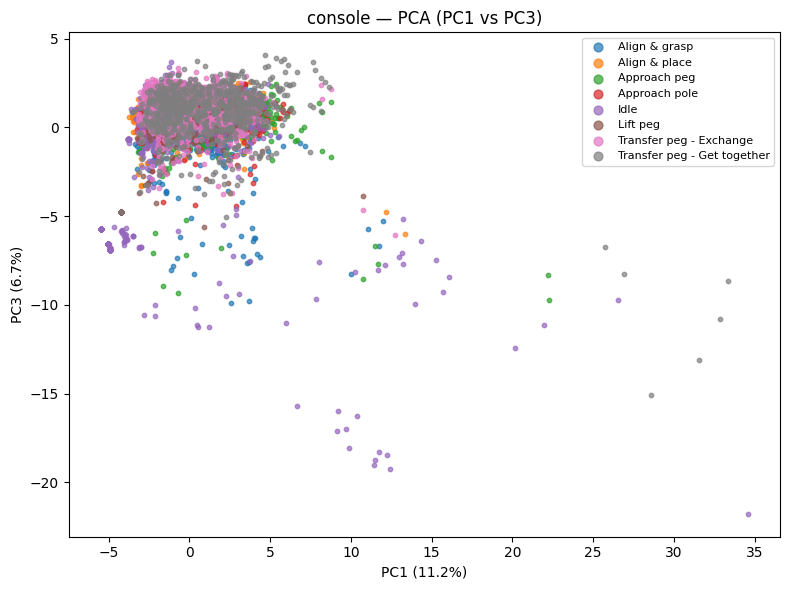

[PCA] Explained variance (first 10): [0.1115 0.0797 0.0666 0.0519 0.0441 0.0398 0.0333 0.0322]
[PCA] Cumulative (first 10): [0.1115 0.1912 0.2578 0.3097 0.3538 0.3936 0.427  0.4592]
[Silhouette (2D)] -0.129  (≈[-1,1], higher=better)


In [52]:
#!/usr/bin/env python3
# PCA/LDA/UMAP on kinematic windows with dynamics (vel/acc) and per-group normalization

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Optional: pip install umap-learn
try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

# ====== USER CONFIG ======
LABEL_COL = None                 # e.g., "gesture" (auto-guess if None)
SUBJECT_COL = None               # e.g., "subject_id" (for per-subject normalization)
TRIAL_COL = None                 # e.g., "trial_id"   (for per-trial normalization)
GROUP_NORM_BY = None             # choose one of the above: "subject", "trial", or None

MODALITY_KEY = "console"           # pick from MODALITY_COLUMNS keys below
METHOD = "pca"                   # "pca", "lda", or "umap" (needs umap-learn)

# Windowing (frames). If your video is 30 Hz, 30=1s, 60=2s
WINDOW_SIZE = 120
WINDOW_HOP = 30

# Feature engineering
USE_VELOCITY = True              # first differences
USE_ACCELERATION = False         # second differences
SMOOTH_SAVGOL = False            # requires scipy; disabled by default
SAVGOL_WINDOW = 7
SAVGOL_POLY = 2

# Dimensionality parameters
N_COMPONENTS = 8                # for PCA
LDA_COMPONENTS = 2               # <= (n_classes - 1)
UMAP_N_COMPONENTS = 2
UMAP_N_NEIGHBORS = 50
UMAP_MIN_DIST = 0.1

# Plot which 2D projection
PC_PAIR = (1, 3)

SAVE_FIGS = True
OUTDIR = Path("./pca_outputs")
# ==========================

# ====== YOUR COLUMNS ======
MODALITY_COLUMNS = {
    "console": [
        "console_pos0","console_pos1","console_pos2","console_pos3","console_pos4","console_pos5",
        "console_rot0","console_rot1","console_rot2","console_rot3","console_rot4","console_rot5",
        "console_aux0","console_aux1","console_pedal"
    ],
    "raven": [
        "raven_field.pos0","raven_field.pos1","raven_field.pos2","raven_field.pos3","raven_field.pos4","raven_field.pos5",
        "raven_field.ori0","raven_field.ori1","raven_field.ori2","raven_field.ori3","raven_field.ori4","raven_field.ori5",
        # optionally more ori channels...
    ],
    "images": ["resnet"],
    "trakstar_raw": [
        "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
        "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
        "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
        "trakstar_sensor_0_x","trakstar_sensor_1_x","trakstar_sensor_2_x","trakstar_sensor_3_x",
        "trakstar_sensor_0_y","trakstar_sensor_1_y","trakstar_sensor_2_y","trakstar_sensor_3_y",
        "trakstar_sensor_0_z","trakstar_sensor_1_z","trakstar_sensor_2_z","trakstar_sensor_3_z"
    ],
    "trakstar_trans": [
        "trakstar_sensor_0_azimuth","trakstar_sensor_1_azimuth","trakstar_sensor_2_azimuth","trakstar_sensor_3_azimuth",
        "trakstar_sensor_0_elevation","trakstar_sensor_1_elevation","trakstar_sensor_2_elevation","trakstar_sensor_3_elevation",
        "trakstar_sensor_0_roll","trakstar_sensor_1_roll","trakstar_sensor_2_roll","trakstar_sensor_3_roll",
        "trakstar_sensor_0_x_transformed","trakstar_sensor_0_y_transformed","trakstar_sensor_0_z_transformed",
        "trakstar_sensor_1_x_transformed","trakstar_sensor_1_y_transformed","trakstar_sensor_1_z_transformed",
        "trakstar_sensor_2_x_transformed","trakstar_sensor_2_y_transformed","trakstar_sensor_2_z_transformed",
        "trakstar_sensor_3_x_transformed","trakstar_sensor_3_y_transformed","trakstar_sensor_3_z_transformed"
    ],
    "sw_left": ["sw_left_x"],
    "sw_right": ["sw_right_x"],
    "handkp": [
        "hand_left X","hand_left Y","hand_left Z","hand_left Yaw","hand_left Pitch","hand_left Roll",
        "hand_right X","hand_right Y","hand_right Z","hand_right Yaw","hand_right Pitch","hand_right Roll"
    ],
}

# ====== HELPERS ======
def guess_label_column(df: pd.DataFrame) -> str:
    preferred = ["gesture","gesture_label","activity","activity_label","label","keystep","keystep_label","gesture_name","class"]
    for p in preferred:
        if p in df.columns or p.title() in df.columns:
            return p if p in df.columns else p.title()
    # fallback: smallest reasonable cardinality non-time column
    candidates = [(c, df[c].nunique()) for c in df.columns if df[c].nunique() > 1 and df[c].nunique() <= 40]
    if candidates:
        candidates.sort(key=lambda x: x[1])
        return candidates[0][0]
    df["_auto_label"] = "all"
    return "_auto_label"

def build_feature_matrix(df: pd.DataFrame, cols: list[str]) -> tuple[np.ndarray, list[str]]:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"[Warn] Missing {len(missing)} columns (showing up to 8): {missing[:8]}")
    used = [c for c in cols if c in df.columns]
    if not used:
        raise ValueError("No requested modality columns found.")
    X = df[used].to_numpy()
    return X, used

def maybe_savgol(x: np.ndarray, window: int, poly: int):
    try:
        from scipy.signal import savgol_filter
    except Exception:
        return x
    if window % 2 == 0: window += 1
    if window < 3: return x
    return savgol_filter(x, window_length=window, polyorder=poly, axis=0, mode="interp")

def add_dynamics(X: np.ndarray, use_vel=True, use_acc=False) -> np.ndarray:
    feats = [X]
    if use_vel:
        V = np.diff(X, n=1, axis=0, prepend=X[:1])
        feats.append(V)
    if use_acc:
        A = np.diff(X, n=2, axis=0, prepend=X[:2])
        feats.append(A)
    return np.concatenate(feats, axis=1)

def windowed_features(X: np.ndarray, y: np.ndarray, win: int, hop: int, reducers=("mean","std","energy")):
    """
    X: [T, D], y: [T] frame labels. Returns Xw [N, D*R], yw [N].
    """
    T, D = X.shape
    idxs = np.arange(0, max(1, T - win + 1), hop)
    out = []
    labels = []
    for s in idxs:
        e = min(T, s + win)
        chunk = X[s:e]
        if chunk.shape[0] == 0: continue
        stats = []
        if "mean" in reducers:  stats.append(chunk.mean(axis=0))
        if "std" in reducers:   stats.append(chunk.std(axis=0, ddof=1))
        if "energy" in reducers: stats.append((chunk**2).mean(axis=0))
        feats = np.concatenate(stats, axis=0)
        out.append(feats)
        # choose majority label in window
        labels.append(pd.Series(y[s:e]).mode(dropna=False).iloc[0])
    return np.vstack(out), np.array(labels)

def groupwise_standardize(df: pd.DataFrame, cols: list[str], group_col: str) -> pd.DataFrame:
    def zscore(g):
        return (g - g.mean()) / (g.std(ddof=1) + 1e-8)
    df = df.copy()
    df[cols] = df.groupby(group_col, observed=True)[cols].transform(zscore)
    return df

# ====== MAIN ======
def main():

    list_of_csvs = ["/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t1/synched_data/final_annotation_t1.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t2/synched_data/final_annotation_t2.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t3/synched_data/final_annotation_t3.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t4/synched_data/final_annotation_t4.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t5/synched_data/final_annotation_t5.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t6/synched_data/final_annotation_t6.csv",
                    "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid/t7/synched_data/final_annotation_t7.csv"]

    df = pd.concat([pd.read_csv(f) for f in list_of_csvs], ignore_index=True)

    # Labels
    label_col = LABEL_COL or guess_label_column(df)
    print(f"[Label] Using: {label_col}")
    y = df[label_col].astype(str).values

    # Group-wise normalization (remove subject/trial confounds)
    if GROUP_NORM_BY == "subject" and SUBJECT_COL and SUBJECT_COL in df.columns:
        cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        df = groupwise_standardize(df, cols, SUBJECT_COL)
        print("[Norm] Per-subject z-scoring applied.")
    elif GROUP_NORM_BY == "trial" and TRIAL_COL and TRIAL_COL in df.columns:
        cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        df = groupwise_standardize(df, cols, TRIAL_COL)
        print("[Norm] Per-trial z-scoring applied.")

    # Build feature matrix from selected modality
    if MODALITY_KEY not in MODALITY_COLUMNS:
        raise KeyError(f"MODALITY_KEY '{MODALITY_KEY}' not in {list(MODALITY_COLUMNS.keys())}")
    X, used_cols = build_feature_matrix(df, MODALITY_COLUMNS[MODALITY_KEY])
    print(f"[Modality] {MODALITY_KEY}: using {len(used_cols)} columns")

    # Optional smoothing
    if SMOOTH_SAVGOL:
        X = maybe_savgol(X, SAVGOL_WINDOW, SAVGOL_POLY)

    # Add dynamics
    X = add_dynamics(X, USE_VELOCITY, USE_ACCELERATION)

    # Window → aggregate stats
    Xw, yw = windowed_features(X, y, WINDOW_SIZE, WINDOW_HOP)

    # Standardize window features
    scaler = StandardScaler()
    Xs = scaler.fit_transform(Xw)

    # Projection
    if METHOD.lower() == "pca":
        n_comp = max(N_COMPONENTS, max(PC_PAIR))
        pca = PCA(n_components=n_comp).fit(Xs)
        Z = pca.transform(Xs)
        i, j = PC_PAIR[0]-1, PC_PAIR[1]-1
        evr = pca.explained_variance_ratio_
        title = f"{MODALITY_KEY} — PCA (PC{PC_PAIR[0]} vs PC{PC_PAIR[1]})"
        xlab = f"PC{PC_PAIR[0]} ({evr[i]:.1%})"; ylab = f"PC{PC_PAIR[1]} ({evr[j]:.1%})"
    elif METHOD.lower() == "lda":
        # LDA dims limited to n_classes-1
        n_classes = np.unique(yw).size
        n_lda = min(LDA_COMPONENTS, max(1, n_classes-1))
        lda = LDA(n_components=n_lda).fit(Xs, yw)
        Z = lda.transform(Xs)
        # project to 2D: if n_lda==1, pad with zeros for plotting
        if Z.shape[1] == 1:
            Z = np.hstack([Z, np.zeros_like(Z)])
        i, j = 0, 1
        title = f"{MODALITY_KEY} — LDA (max separation)"
        xlab = "LD1"; ylab = "LD2"
    elif METHOD.lower() == "umap":
        if not HAS_UMAP:
            raise RuntimeError("umap-learn not installed. `pip install umap-learn`")
        reducer = umap.UMAP(n_components=UMAP_N_COMPONENTS, n_neighbors=UMAP_N_NEIGHBORS,
                            min_dist=UMAP_MIN_DIST, metric="euclidean", random_state=42)
        Z = reducer.fit_transform(Xs)
        # if n_components>2, take first 2 for plotting
        i, j = 0, 1
        title = f"{MODALITY_KEY} — UMAP (n={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST})"
        xlab = "UMAP-1"; ylab = "UMAP-2"
    else:
        raise ValueError("METHOD must be 'pca', 'lda', or 'umap'.")

    # Plot
    plt.figure(figsize=(8,6))
    cats = pd.Series(yw).astype("category")
    codes = cats.cat.codes.values
    for code in np.unique(codes):
        sel = codes == code
        plt.scatter(Z[sel, i], Z[sel, j], s=10, alpha=0.7, label=str(cats.cat.categories[code]))
    plt.xlabel(xlab); plt.ylabel(ylab); plt.title(title)
    plt.legend(markerscale=2, fontsize=8, loc="best")
    plt.tight_layout()
    if SAVE_FIGS:
        OUTDIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(OUTDIR / f"{MODALITY_KEY}_{METHOD}_scatter.png", dpi=200)
    plt.show()

    # Diagnostics
    if METHOD.lower() == "pca":
        cum = np.cumsum(evr)
        print("[PCA] Explained variance (first 10):", np.round(evr[:10], 4))
        print("[PCA] Cumulative (first 10):", np.round(cum[:10], 4))
    # Silhouette on the plotted 2D
    if len(np.unique(yw)) > 1:
        try:
            sil = silhouette_score(Z[:, [i, j]], cats.cat.codes.values)
            print(f"[Silhouette (2D)] {sil:.3f}  (≈[-1,1], higher=better)")
        except Exception as e:
            print(f"[Silhouette] failed: {e}")

main()
